# Cosmology with GWs/FRBs Associations (without redshift information)

Based on [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)].

In [1]:
import sys
sys.path.append('../Python_scripts')

__Importing modules and constants__

In [2]:
from config import *

__Importing useful support functions__

In [3]:
from support import *

__Importing cosmological functions__

In [5]:
from cosmo_support import *

----------------------------------------------

## Basic definitions

We are defining the **luminosity distance**, observed through GWs:

$$
d_L = \frac{(1+z) c}{H_0} \int_0^z \frac{dz}{\sqrt{\Omega_m(1+z)^3+(1-\Omega_m)(1+z)^{3(1+w)}}}.
$$

For a cosmological constant, $w=-1$.

We are defining the IGM **dispersion measure (DM)**, based on [[Deng & Zhang, 2014](https://iopscience.iop.org/article/10.1088/2041-8205/783/2/L35/pdf)], eq (13) and eq. (12) of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)]:

$$
{\rm DM}_{\rm IGM} = \frac{3 c H_0 \Omega_b f_{\rm IGM}}{8 \pi G m_p} \int_0^z \frac{\chi(z) (1+z) dz}{\sqrt{\Omega_m(1+z)^3+(1-\Omega_m)(1+z)^{3(1+w)}}} 
$$


Assuming redshifts $z<2$, we use $\chi(z) \simeq 7/8$ - this assumes that the Universe is fully ionised at that time. For higher redshifts, the ionisation history of H and He needs to be modelled.

For the test cases, we assume the following **error estimates**:

- For the luminosity distance:

$$
\sigma_{d_L} = \sqrt{\left( \frac{2d_L}{\rho} \right)^2 + (0.05 z d_L)^2}.
$$

Since for the test cases we are not going to model any realistic GWs signals, we will either assume a signal-to-noise ratio $\rho = 8$, for all events (this is a conservative estiamte), or we will assume a constant error (of 10%) on the luminosity distance of $\sigma_{d_L} \sim 0.1 d_L$.

- For the dispersion measure:

We have contributions from the MW ${\rm DM}_{\rm MW}$, the observational limitations ${\rm DM}_{\rm obs}$, the intergalactic medium ${\rm DM}_{\rm IGM}$, the host galaxy ${\rm DM}_{\rm HG}$ and potentially the source itself ${\rm DM}_{\rm HG}$. Some fiducial values based on [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)] are [in pc/cm$^3$]:

$$
\sigma_{\rm MW} \sim 10, \quad \sigma_{\rm obs} \sim 1.5, \quad \sigma_{\rm IGM} \sim 100, \quad \sigma_{\rm HG} \sim 30,
$$

and are combined to:

$$
\sigma_{\rm DM} = \sqrt{\sigma_{\rm MW}^2+\sigma_{\rm obs}^2+\sigma_{\rm IGM}^2+\left(\frac{\sigma_{\rm HG}}{1+z}\right)^2},
$$

while a conservative estimate leads to a $\sigma_{{\rm DM}} \sim 105$ pc/cm$^3$.

-----------------------------------------

## Reproduction of basic results

As a sanity check of our cosmological code, we start by a quick reproduction of the basic resutls of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)]. 


<div class="alert alert-block alert-warning">
  <b>NB:</b> Our method is going to be simplified, i.e. we are going to use a simpler population model (for the test case) and just one repetition.
</div>


For this part, we put cosmological constraints, utilising the joint product $d_L \cdot {\rm DM}$. This method assumes **redshift information** from detecting the host of the FRB/GW. To put constraints we are following their $\chi^2$ approach:

$$
\chi^2 (\Omega_m, w) = \frac{[d_L^{\rm obs} \cdot {\rm DM}^{\rm obs}-d_L \cdot {\rm DM}(\Omega_m, w)]^2}{\sigma_{d_L{\rm DM}}^2},
$$

where we calculate the errors as:

$$
\sigma_{d_L \rm DM} = \sqrt{\left({\rm DM} \cdot \sigma_{d_L}\right)^2+ \left( d_L \cdot \sigma_{\rm DM} \right)^2 }.
$$

**Creation of mock events** (simplified)

We draw some random redshifts from $[z_{\min}, z_{\max}]$. For these, and the fiducial cosmology, we calculate luminosity distances and DMs, and their respective errors. The mock obsersations are based on these but with scatter that follows a guassian distribution, e.g. $DM^{\rm obs} = \mathcal{N}({\rm DM}(z, H^f_0, \Omega_m^f, w^f), \sigma_{\rm DM})$.

We then use the redshifts and the $\chi^2$ statistic to put constraints on $\Omega_m$ and $w$.

In [6]:
z_range = np.linspace(0.2, 2.0, 500)

z_obs = np.random.choice(z_range, size=50, replace=False)

dL_values_fid = np.zeros_like(z_range)
DM_values_fid = np.zeros_like(z_range)
dLDM_fid = np.zeros_like(z_range)

dL_values_obs = np.zeros_like(z_obs)
DM_values_obs = np.zeros_like(z_obs)
s_dL_obs = np.zeros_like(z_obs)

dLDM_obs = np.zeros_like(z_obs)
s_dLDM_obs = np.zeros_like(z_obs)

for idx, z_val in enumerate(z_obs): 
    dL_fid = luminosity_distance(z_val, HUBBLE, OMEGA_MATTER, w=-1)
    DM_fid = dispersion_measure(z_val, HUBBLE, OMEGA_MATTER, w=-1)
    
    s_dL_obs[idx] = sigma_dL(z_val, HUBBLE, OMEGA_MATTER, w=-1, method='Wei')
    s_DM_fid = SIGMA_DM
    
    dL_values_obs[idx] = np.random.normal(dL_fid, s_dL_obs[idx])
    DM_values_obs[idx] = np.random.normal(DM_fid, s_DM_fid)
    
    dLDM_obs[idx] = dL_values_obs[idx]*DM_values_obs[idx]
    s_dLDM_obs[idx] = sigma_dLDM(dL_values_obs[idx], DM_values_obs[idx], s_dL_obs[idx])
    
    
for idx, z_val in enumerate(z_range): 
    dL_values_fid[idx] = luminosity_distance(z_val, HUBBLE, OMEGA_MATTER, w=-1)
    DM_values_fid[idx] = dispersion_measure(z_val, HUBBLE, OMEGA_MATTER, w=-1)   
    dLDM_fid[idx] = dLDM_measure(z_val, HUBBLE, OMEGA_MATTER, w=-1)

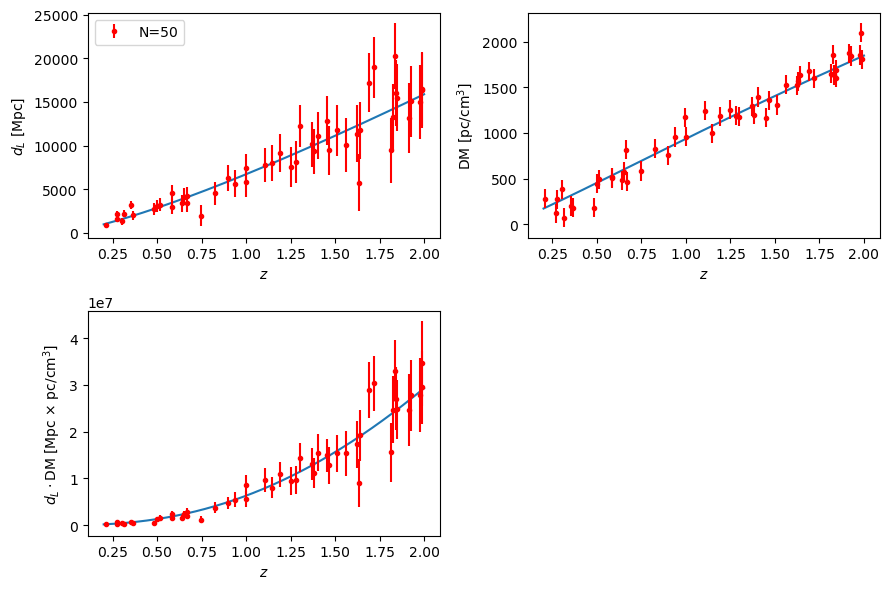

In [9]:
fig = plt.figure(figsize=(9,6))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)

ax1.plot(z_range, dL_values_fid)
ax1.errorbar(z_obs, dL_values_obs, yerr=s_dL_obs, marker='o', ls='', ms=3, c='r', label=f'N={len(z_obs)}')
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left')

ax2.plot(z_range, DM_values_fid)
ax2.errorbar(z_obs, DM_values_obs, yerr=SIGMA_DM, marker='o', ls='', ms=3, c='r')
ax2.set_ylabel(r'DM [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')

ax3.plot(z_range, dLDM_fid)
ax3.errorbar(z_obs, dLDM_obs, yerr=s_dLDM_obs, marker='o', ls='', ms=3, c='r')
ax3.set_ylabel(r'$d_{L} \cdot {\rm DM}$ [Mpc $\times$ pc/cm$^3$]')
ax3.set_xlabel(r'$z$')

plt.tight_layout()
plt.show()

In [10]:
Omega_m_array = np.linspace(0.0, 0.6, 100)
w_array = np.linspace(-3.0, 0.0, 140)

Om_, w_ = np.meshgrid(Omega_m_array, w_array)

In [11]:
### Fitting Om        
chi_fit = np.zeros_like(Omega_m_array) + Omega_m_array.size

for idx_Om, Om in enumerate(Omega_m_array):
    chi_square = 0
    for idx_z, z_val in enumerate(z_obs):
        dLDM = dLDM_measure(z_val, HUBBLE, Om, w=-1)        
            
        chi_square += (dLDM_obs[idx_z]-dLDM)**2/s_dLDM_obs[idx_z]**2  # For all events, add in χ^2
       
    chi_fit[idx_Om] = chi_square

In [12]:
### Finding the best-fit Om & error 
### See P. Gregory, p.260

## Find Om value
chi_1D_min = np.min(chi_fit)
id_Om_min = np.where(chi_fit==chi_1D_min)[0][0]

## Find sigma
sigma1_chi_fit = chi_1D_min+1
delta_chi = np.abs(chi_fit-sigma1_chi_fit)
delta_chi_min = np.min(delta_chi)
id_Om_sigma_1 = np.where(delta_chi==delta_chi_min)[0][0]

## Transform to the physical parameter of interest
Omega_fit = Omega_m_array[id_Om_min]
sigma_Om = np.abs(Omega_m_array[id_Om_min]-Omega_m_array[id_Om_sigma_1])

In [ ]:
### Fitting Om & w
chi_fit_2D = np.zeros_like(Om_) + Om_.size

for idx_Om, Om in enumerate(Omega_m_array):
    for idx_w, w_val in enumerate(w_array):
        chi_square = 0
        for idx_z, z_val in enumerate(z_obs):
            dLDM = dLDM_measure(z_val, HUBBLE, Om, w=w_val)        
            
            chi_square += (dLDM_obs[idx_z]-dLDM)**2/s_dLDM_obs[idx_z]**2
    
        chi_fit_2D[idx_w, idx_Om] = chi_square     

In [ ]:
fig = plt.figure(figsize=(9, 7))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax4 = fig.add_subplot(224)


ax1.plot(Omega_m_array, chi_fit/(len(z_obs)-1))
ax1.axvline(x=OMEGA_MATTER, ls='--', c='black')
ax1.set_xlabel(r'$\Omega_m$')
ax1.set_ylabel(r'$\chi^2/n_{\rm eff}$')


### NOTE: Contours to be checked
chi_2D_min = np.min(chi_fit_2D)
ax2.contour(Om_, w_, chi_fit_2D, levels=[chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues')
ax2.scatter(OMEGA_MATTER, -1, marker='+', c='r')
ax2.set_xlabel(r'$\Omega_m$')
ax2.set_ylabel(r'$w$')

ax4.plot(Omega_m_array, normalise(Gaussian(Omega_m_array, Omega_fit, sigma_Om)), label=fr'$N$ = {len(z_obs)}')
ax4.axvline(x=OMEGA_MATTER, ls='--', c='black')
ax4.set_xlabel(r'$\Omega_m$')
ax4.set_ylabel('pdf')
ax4.legend()

plt.tight_layout()
plt.show()

**NB**: Compare with Figures 3 & 4 of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)].

<div class="alert alert-block alert-danger">
<b>NB:</b> MK - Need to edit below!
</div>

------------------------------------------

# Ideal luminosity distances (proof of concept)

When we do not have redshift information, we can use $d_L$ (luminosity distance) from GWs and ${\rm DM}_{\rm IGM}$ from the FRBs to put constraints on the cosmological parameters ($H_0, \Omega_m$).

In this simplified case, we assume idealised $d_L$, i.e. precise determination of distances. Then, we can calculate:

$$
d_L^{\rm obs}\quad \underrightarrow{(H_0, \Omega_m)}\quad z \quad \underrightarrow{(H_0, \Omega_m)}\quad {\rm DM},
$$

which can then be compared to ${\rm DM}^{\rm obs}$, with the standard $\chi^2$ statistic


$$
\chi^2 (H_0, \Omega_m) = \frac{[{\rm DM}^{\rm obs}-{\rm DM}(H_0, \Omega_m)]^2}{\sigma_{{\rm DM}}^2},
$$

where for $\sigma_{{\rm DM}}$ we assume a value of $\sigma_{{\rm DM}} \sim 105$ pc/cm$^3$.

#### **Creation of mock events** (very simplified)

We draw some random distances from $[L_{\min}, L_{\max}]$, from them we find redshifts, based on the fiducial cosmology $(H^f_0, \Omega_m^f)$. With the redshifts we calculate the mock $DM$, following $DM^{\rm obs} = \mathcal{N}({\rm DM}(z, H^f_0, \Omega_m^f), \sigma_{\rm DM})$.

With these we calculate the $\chi^2$ statistic and constrain cosmology.

In [62]:
## Distances range
dL_range = np.linspace(1000, 20000, 100)

## Choose N random distances, i.e. random events, from the distance range
d_luminosity = np.random.choice(dL_range, size=15, replace=False)
d_luminosity = np.sort(d_luminosity)  # Just to simplify plotting - not affecting anything else

## Calculate redshifts for these distances based on fiducial cosmology
cosmo_fid = FlatLambdaCDM(H0=HUBBLE, Om0=OMEGA_MATTER)
redshifts = z_at_value(cosmo_fid.luminosity_distance, d_luminosity*u.Mpc).value

In [63]:
DM_theory = []
DM_obs = []

sigma_DM = 105

for z_val in redshifts:
    DM = dispersion_measure(z_val, OMEGA_MATTER, HUBBLE)
    DM_theory.append(DM)
    DM_obs.append(np.random.normal(DM, sigma_DM))    

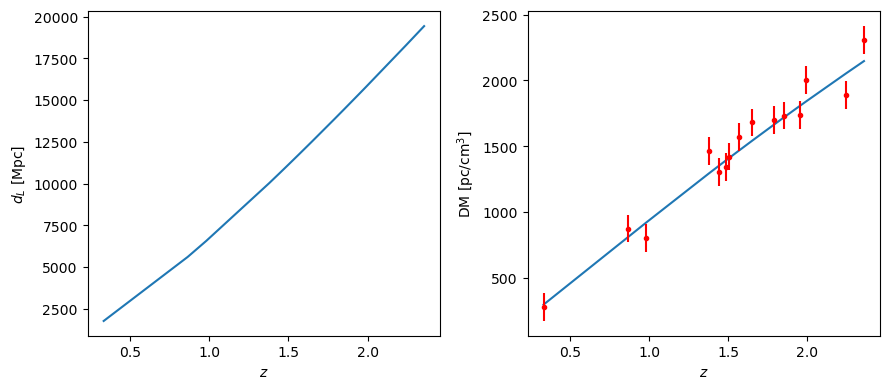

In [64]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(redshifts, d_luminosity)
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')

ax2.plot(redshifts, DM_theory)
ax2.errorbar(redshifts, DM_obs, yerr=sigma_DM, marker='o', ls='', ms=3, c='r')
ax2.set_ylabel(r'DM [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')

plt.tight_layout()
plt.show()

**Cosmological inference**

Considering the cases of $\Omega_m$ fixed or not.

In [65]:
H0_array = np.linspace(10, 140, 140)
Omega_m_array = np.linspace(0.1, 0.5, 100)

H_, Om_ = np.meshgrid(H0_array, Omega_m_array)

In [66]:
### Fitting only H0

chi_fit = []

for idx, H0 in enumerate(H0_array):
    log_chi=0
    for idx_z, z_val in enumerate(redshifts):
        DM = dispersion_measure(z_val, OMEGA_MATTER, H0)
        
        log_chi += (DM_obs[idx_z]-DM)**2/sigma_DM**2  # For all events, add in χ^2
    
    chi_fit.append(log_chi)
    
chi_fit = np.array(chi_fit)    

In [67]:
### Fitting H0 & Om

chi_fit_2D = np.zeros_like(H_) + H_.size

for idx_H, H0 in enumerate(H0_array):
    for idx_Om, Om in enumerate(Omega_m_array):
        log_chi=0
        for idx_z, z_val in enumerate(redshifts):
            DM = dispersion_measure(z_val, Om, H0)
        
            log_chi += (DM_obs[idx_z]-DM)**2/sigma_DM**2
    
        chi_fit_2D[idx_Om, idx_H] = log_chi

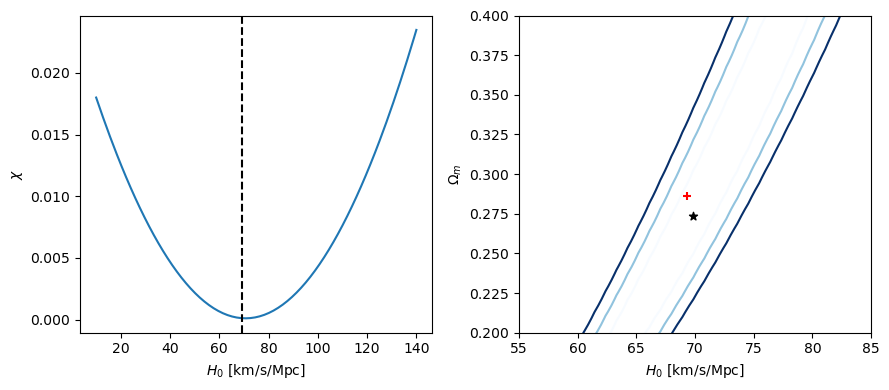

In [72]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(H0_array, chi_fit/np.sum(chi_fit))
ax1.axvline(x=HUBBLE, ls='--', c='black')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax1.set_ylabel(r'$\chi$')


### NOTE: Contours to be checked
chi_2D_min = np.min(chi_fit_2D)
ax2.contour(H_, Om_, chi_fit_2D, levels=[chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues')
ax2.scatter(H0_array[64], Omega_m_array[43], marker='*', c='black')
ax2.scatter(HUBBLE, OMEGA_MATTER, marker='+', c='r')
ax2.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax2.set_ylabel(r'$\Omega_m$')
ax2.set_xlim(55, 85)
ax2.set_ylim(0.2, 0.4)

plt.tight_layout()
plt.show()

# Distances with errors

Now take into account that distances can have errors - for a range of redshifts calculate the posteriors and marginalise over redshift:

$$
\int dz \ P\left(d_L^{\rm obs}|d_L(z, H_0, \Omega_m)\right) \cdot P\left({\rm DM}^{\rm obs}|{\rm DM}(z, H_0, \Omega_m)\right)
$$

<div class="alert alert-block alert-danger">
<b>NB:</b> Extra things to consider: 
<br>
    - Any extra priors needed? Will depend on the data generation process <br>
    - Marginalisation over DM uncertainties <br>
    - Selection effects?
    
</div>

### **1 event**

We choose a redshift, and create an observational $d_L^{\rm obs}$ and ${\rm DM}^{\rm obs}$ distribution.

In [25]:
## Random choice of redshift
z_centre = 0.6

# Theoretical dL, fiducial cosmo
cosmo_fid = FlatLambdaCDM(H0=HUBBLE, Om0=OMEGA_MATTER)
dL_centre = cosmo_fid.luminosity_distance(z_centre).value

# Theoretical DM, fiducial cosmo
DM_centre = dispersion_measure(z_centre, OMEGA_MATTER, HUBBLE)

We create the distance posteriors, by moving around the central values and arruming observational errors

In [26]:
## Choice of observed luminosity distance
sigma_dL = 0.1*dL_centre
dL_obs_centre = np.random.normal(dL_centre, sigma_dL)

## Choice of observed DM
sigma_DM = 105
DM_obs_centre = np.random.normal(DM_centre, sigma_DM)

In [27]:
## Creating the posteriors around the observed values

dL_gaussian = np.random.normal(dL_obs_centre, sigma_dL, 1000)

DM_gaussian = np.random.normal(DM_obs_centre, sigma_DM, 1000)

<div class="alert alert-block alert-danger">
<b>NB:</b> Need to make sure to avoid unphysical (negative) values!
</div>

In [29]:
## Fitting KDEs around the observed events
GW_dL_kde = gaussian_kde(dL_gaussian)
FRB_DM_kde = gaussian_kde(DM_gaussian)

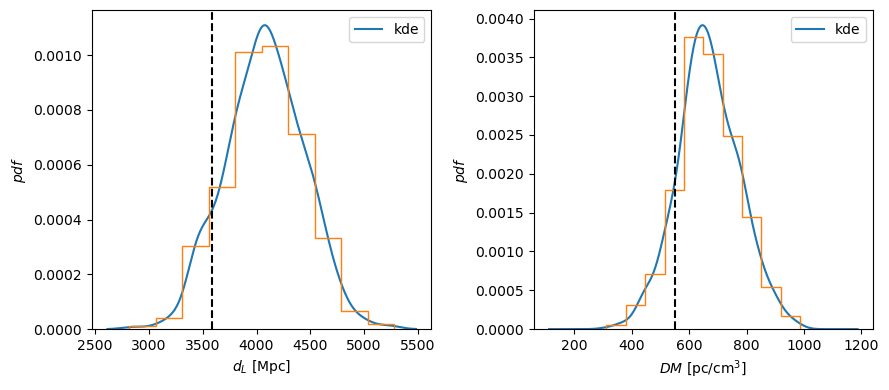

In [33]:
dl_array=np.linspace(np.min(dL_gaussian)-200, np.max(dL_gaussian)+200, 500)
DM_array=np.linspace(np.min(DM_gaussian)-200, np.max(DM_gaussian)+200, 500)

fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(dl_array, GW_dL_kde(dl_array), label='kde')
ax1.hist(dL_gaussian, density=True, histtype='step')
ax1.axvline(x=dL_centre, ls='--', c='black')
ax1.set_xlabel(r'$d_L$ [Mpc]')
ax1.set_ylabel(r'$pdf$')
ax1.legend()


ax2.plot(DM_array, FRB_DM_kde(DM_array), label='kde')
ax2.hist(DM_gaussian, density=True, histtype='step')
ax2.axvline(x=DM_centre, ls='--', c='black')
ax2.set_xlabel(r'$DM$ [pc/cm$^3$]')
ax2.set_ylabel(r'$pdf$')
ax2.legend()

plt.tight_layout()
plt.show()

We now create a redshift range capable of covering the full range of $d_L$ and ${\rm DM}$.

In [34]:
## Redshift range
z_array=np.linspace(0.2, 1.2, 200)

## Luminosity distance and DM range for fiducial cosmology (for visualisation purposes)
lum_distance = FlatLambdaCDM(H0=HUBBLE, Om0=OMEGA_MATTER).luminosity_distance(z_array).value

DM_distance = []
for z_val in z_array:
    DM_distance.append(dispersion_measure(z_val, Om=OMEGA_MATTER, H0=HUBBLE))
    
DM_distance = np.array(DM_distance)

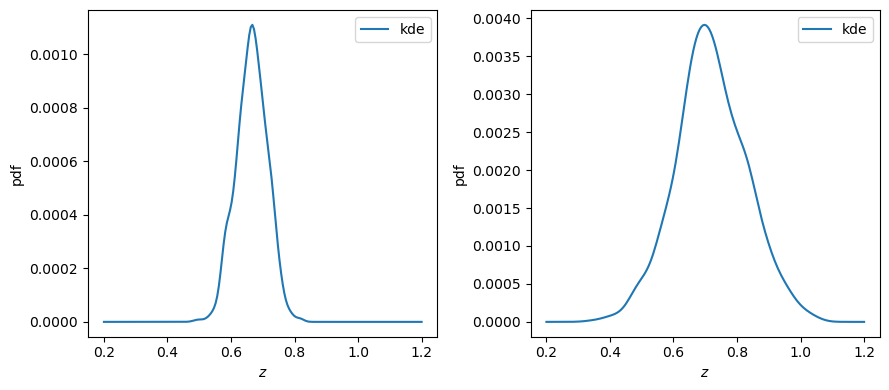

In [36]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(z_array, GW_dL_kde(lum_distance), label='kde')
ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'pdf')
ax1.legend()


ax2.plot(z_array, FRB_DM_kde(DM_distance), label='kde')
ax2.set_xlabel(r'$z$')
ax2.set_ylabel(r'pdf')
ax2.legend()

plt.tight_layout()
plt.show()

**$H_0$ inference, assuming a fixed $\Omega_m$**. 

For a given $H_0$, we produce a distance and DM range and weight compared to our observed pdfs for $d_L$ and ${\rm DM}$. Since these two observations were made independently, we multiply their LHDs.

In [37]:
H0_array = np.linspace(20,120, 200)
posterior_normed = np.zeros_like(H0_array)

for i, H0 in enumerate(H0_array):
    lum_distance = FlatLambdaCDM(H0=H0, Om0=OMEGA_MATTER).luminosity_distance(z_array).value

    DM_distance = []
    for z_val in z_array:
        DM_distance.append(dispersion_measure(z_val, Om=OMEGA_MATTER, H0=H0))

    DM_distance = np.array(DM_distance)
    
    # Integrate out the redshift dependence
    posterior_normed[i] = np.trapz(GW_dL_kde(lum_distance)*FRB_DM_kde(DM_distance), z_array)

## Normalise posterior
posterior_normed/=np.trapz(posterior_normed, H0_array)

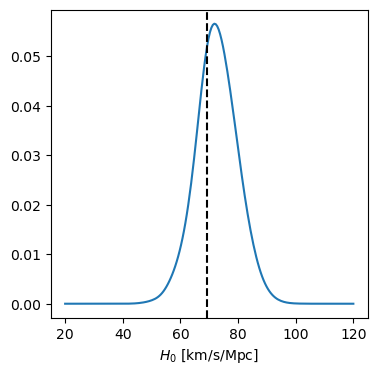

In [39]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)

ax1.plot(H0_array, posterior_normed, label='kde')
ax1.axvline(x=HUBBLE, ls='--', c='black')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')

plt.show()

### **Multiple events**

Extend the analysis above to multiple events

<div class="alert alert-block alert-danger">
<b>NB:</b> Under progress!
</div>

In [42]:
## Random choice of redshifts
zs_centre = np.random.choice(np.linspace(0.5, 1.5, 20), size=5)

dL_centres = cosmo_fid.luminosity_distance(zs_centre).value

DM_centres = []
for z_val in zs_centre:
    DM_centres.append(dispersion_measure(z_val, OMEGA_MATTER, HUBBLE))

In [43]:
## Choice of observed luminosity distance
sigma_dL = 0.1*dL_centres

## Choice of observed DM
sigma_DM = 105

dL_obs_centres = np.zeros_like(zs_centre)
DM_obs_centres = np.zeros_like(zs_centre)

for idx, dL in enumerate(dL_centres):
    dL_obs_centres[idx] = np.random.normal(dL, sigma_dL[idx])
    DM_obs_centres[idx] = np.random.normal(DM_centres[idx], sigma_DM)

In [ ]:


dL_gaussian = np.random.normal(dL_obs_centre, sigma_dL, 1000)
DM_gaussian = np.random.normal(DM_obs_centre, sigma_DM, 1000)


## Fitting KDEs around the observed events
GW_dL_kde = gaussian_kde(dL_gaussian)
FRB_DM_kde = gaussian_kde(DM_gaussian)

-----------------------

# Appendix

## A1 - Checking cosmological functions

1. Reproduce Figure 2 of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)], to check ourdefinitions of luminosity distance and dispersion measure.

In [5]:
z_range = np.linspace(0.2, 2.0, 50)

dL_values_astropy = FlatLambdaCDM(H0=HUBBLE, Om0=OMEGA_MATTER).luminosity_distance(z_range).value

dL_values = np.zeros_like(z_range)
DM_values = np.zeros_like(z_range)

for idx, z_val in enumerate(z_range): 
    dL_values[idx] = luminosity_distance(z_val, HUBBLE, OMEGA_MATTER, w=-1)
    DM_values[idx] = dispersion_measure(z_val, HUBBLE, OMEGA_MATTER, w=-1)

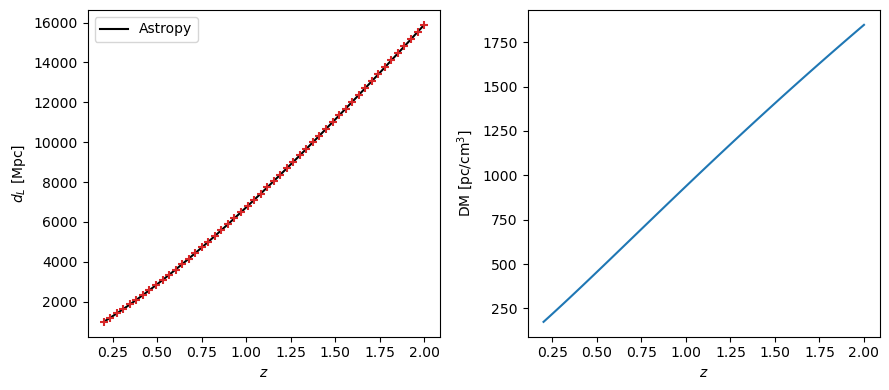

In [8]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(z_range, dL_values_astropy, ls='-', c='black', label='Astropy')
ax1.scatter(z_range, dL_values, s=35, marker='+', c='tab:red', zorder=10)
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
ax1.legend()

ax2.plot(z_range, DM_values)
ax2.set_ylabel(r'DM [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')

plt.tight_layout()
plt.show()

2. Check that `dLDM_measure` is the same as $dL \cdot {\rm DM}$. Normalise wrt Einstein-deSitter (EdS) Universe, i.e. $\Omega_m = 1$, to compare with FIgure 1 (right), pink line of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)].

In [12]:
dLDM_theory = dL_values*DM_values
dLDM_values = np.zeros_like(z_range)
dLDM_values_EdS = np.zeros_like(z_range)


for idx, z_val in enumerate(z_range): 
    dLDM_values[idx] = dLDM_measure(z_val, HUBBLE, OMEGA_MATTER, w=-1)
    dLDM_values_EdS[idx] = dLDM_measure(z_val, HUBBLE, Om=1, w=-1)    

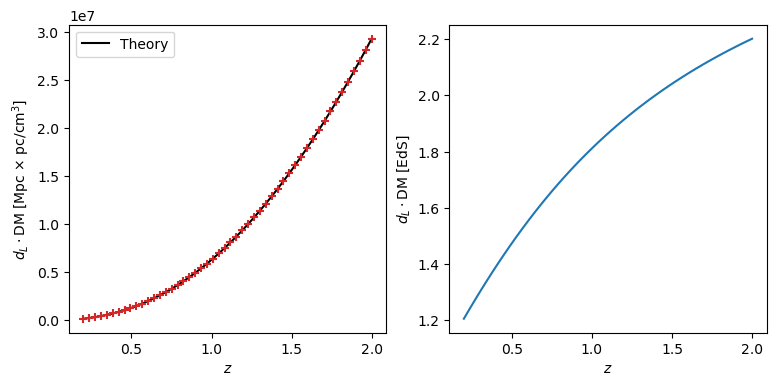

In [13]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)


ax1.plot(z_range, dLDM_theory, ls='-', c='black', label='Theory')
ax1.scatter(z_range, dLDM_values, s=35, marker='+', c='tab:red', zorder=10)
ax1.set_ylabel(r'$d_{L} \cdot {\rm DM}$ [Mpc $\times$ pc/cm$^3$]')
ax1.set_xlabel(r'$z$')
ax1.legend()

ax2.plot(z_range, dLDM_values/dLDM_values_EdS)
ax2.set_ylabel(r'$d_{L} \cdot {\rm DM}$ [EdS]')
ax2.set_xlabel(r'$z$')

plt.show()